# 02 — Returns and Statistics: measuring reward and risk

## What you'll learn
- The difference between **simple** and **log (continuously compounded)** returns, and when each is used.
- How to visualise the distribution of daily returns and overlay a normal curve computed from scratch.
- How to build a **"growth of $1"** curve to compare two stocks fairly.
- The three core risk numbers: **annualised volatility**, **maximum drawdown**, and the **Sharpe ratio** (and what the zero-risk-free shortcut hides).

A raw price chart tells you a stock went from \$100 to \$120, but not how bumpy the ride was.
Returns strip out the price level so two stocks — and two time periods — become comparable.
From here on, almost every statistic in finance is built on the return series.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from stocklearn.data import get_history, price_series
from stocklearn.indicators import (
    daily_returns, log_returns, annualized_volatility, max_drawdown, sharpe_ratio,
)

sns.set_theme(style="whitegrid")

# Swap these in one place to explore other companies.
ticker = "AAPL"
other = "MSFT"
period = "1y"

## Load and align two price series

We fetch both tickers through `stocklearn` and take the **adjusted close** (`price_series`
returns `Adj Close` when Yahoo provides it). Adjusted prices fold in splits and dividends,
so the return series reflects what an investor actually earned.

The two series may have slightly different trading calendars (holidays, listings). We align
them with an **inner join** so every date has a price for *both* stocks — otherwise a
comparison of "growth of \$1" would compare different date ranges.

In [2]:
df_a = get_history(ticker, period=period)
df_b = get_history(other, period=period)

# Adjusted close for each ticker, then an inner join on the shared dates.
close_a = price_series(df_a).rename(ticker)
close_b = price_series(df_b).rename(other)
prices = pd.concat([close_a, close_b], axis=1, join="inner").dropna()

print(f"aligned rows: {len(prices)}   range: {prices.index[0].date()} -> {prices.index[-1].date()}")
prices.tail()

aligned rows: 251   range: 2025-10-03 -> 2026-10-02


,AAPL,MSFT
Date,,
2026-09-28 00:00:00-04:00,338.399994,509.220001
2026-09-29 00:00:00-04:00,329.399994,508.959991
2026-09-30 00:00:00-04:00,333.019989,512.900024
2026-10-01 00:00:00-04:00,330.320007,512.799988
2026-10-02 00:00:00-04:00,333.690002,517.530029


## Simple vs log returns

- **Simple return**: `r_t = P_t / P_{t-1} - 1`. This is the number a broker statement shows
  ("you made 2% today"). It is what actually multiplies your money: your wealth grows by
  `(1 + r_t)` each day.
- **Log return**: `l_t = ln(P_t / P_{t-1})`. It answers the same question but on a
  logarithmic scale.

Why bother with two? Because **log returns add up over time** while simple returns multiply.
The return over two days is exactly `l_1 + l_2` in log space, which makes multi-period
maths and volatility scaling easy. For small moves the two are nearly identical
(`ln(1+r) ≈ r`), but they diverge as moves get large — a +50% simple return is `ln(1.5) ≈ 0.405`
in log space. Rule of thumb: use **simple** returns for wealth/P&L, **log** returns for
statistics and aggregation.

In [3]:
ret_simple = daily_returns(prices)
ret_log = log_returns(prices)

# Compare a small sample side by side for just the first ticker.
sample = pd.DataFrame({
    "simple": ret_simple[ticker],
    "log": ret_log[ticker],
})
sample["difference"] = sample["simple"] - sample["log"]
sample.head(6)

,simple,log,difference
Date,,,
2025-10-03 00:00:00-04:00,NaN,NaN,NaN
2025-10-06 00:00:00-04:00,-0.005155,-0.005168,1.333157e-05
2025-10-07 00:00:00-04:00,-0.000818,-0.000818,3.347393e-07
2025-10-08 00:00:00-04:00,0.006160,0.006141,1.889657e-05
2025-10-09 00:00:00-04:00,-0.015578,-0.015700,1.226074e-04
2025-10-10 00:00:00-04:00,-0.034522,-0.035132,6.099691e-04


Notice the difference column: it is tiny on ordinary days and only grows on big moves.
Also check the bottom row of the table (the first real day): cumulative log returns equal the
sum of the daily logs, whereas cumulative simple returns must be compounded with
`(1 + r).prod()`.

The histogram below shows the day-to-day distribution of Apple's returns. Most days cluster
near zero, with a few large moves in both directions. The red curve is a **normal
distribution** fitted to the data using only numpy — no scipy needed. Real return
distributions have "fat tails" (more extreme days than the normal predicts), which is the
first hint that market risk is not perfectly bell-shaped.

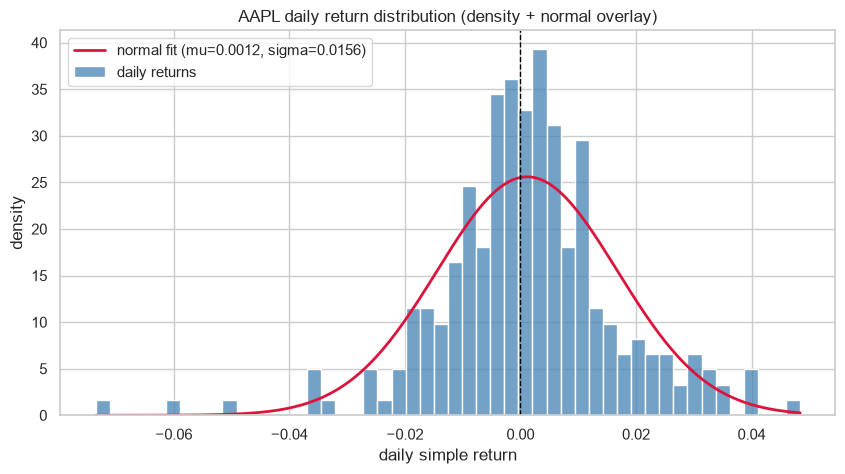

In [4]:
r = ret_simple[ticker].dropna()
mu, sigma = r.mean(), r.std()

# Normal probability density, computed from scratch:
#   pdf(x) = exp(-0.5 * z^2) / (sigma * sqrt(2*pi)),  z = (x - mu) / sigma
x = np.linspace(r.min(), r.max(), 200)
z = (x - mu) / sigma
pdf = np.exp(-0.5 * z**2) / (sigma * np.sqrt(2 * np.pi))

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(r, bins=50, stat="density", ax=ax, color="steelblue", label="daily returns")
ax.plot(x, pdf, color="crimson", lw=2, label=f"normal fit (mu={mu:.4f}, sigma={sigma:.4f})")
ax.axvline(0, color="black", lw=1, ls="--")
ax.set_title(f"{ticker} daily return distribution (density + normal overlay)")
ax.set_xlabel("daily simple return")
ax.set_ylabel("density")
ax.legend()
plt.show()

## Growth of \$1

Compounding answers the question "what would \$1 invested at the start be worth now?".
Multiply `(1 + r_t)` across all days for each stock (equivalently, `cumprod`). Because we
aligned the two series, the curves start at the same date and \$1 — a fair race. Note this
ignores dividends *paid out of* the adjusted series only in the sense that adj close
reinvests them; it is the standard total-return approximation.

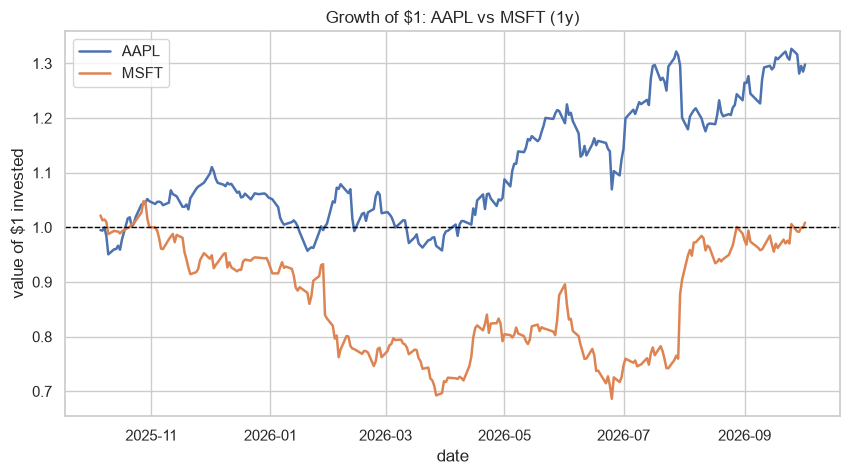

In [5]:
growth = (1 + ret_simple).cumprod()

fig, ax = plt.subplots(figsize=(10, 5))
for col in growth.columns:
    ax.plot(growth.index, growth[col], label=col, lw=1.8)
ax.axhline(1.0, color="black", lw=1, ls="--")
ax.set_title(f"Growth of $1: {ticker} vs {other} ({period})")
ax.set_ylabel("value of $1 invested")
ax.set_xlabel("date")
ax.legend()
plt.show()

## Risk 1: annualised volatility

**Volatility** is the standard deviation of returns — how widely the daily moves scatter
around their average. We annualise it by multiplying the daily standard deviation by
`sqrt(252)` (roughly the number of trading days in a year), under the assumption that daily
returns are independent. Higher volatility means a wider range of outcomes: more risk.

**Maximum drawdown** is the largest peak-to-trough fall over the period, e.g. `-0.31` means
the stock at its worst was down 31% from a prior high. Unlike volatility it captures the
*sequence* of losses — the pain of watching your money shrink.

In [6]:
risk = pd.DataFrame({
    "annualized_volatility": {c: annualized_volatility(prices[c]) for c in prices.columns},
    "max_drawdown": {c: max_drawdown(prices[c]) for c in prices.columns},
})
risk

,annualized_volatility,max_drawdown
AAPL,0.247364,-0.137985
MSFT,0.328258,-0.344984


### The drawdown curve

Volatility and drawdown are single numbers; the **drawdown curve** shows the whole story.
For each day, `close / cummax(close) - 1` measures how far below the running high you are.
It is always `<= 0`, touches zero at each new high, and plunges during sell-offs — a much
more intuitive picture of risk than a standard deviation.

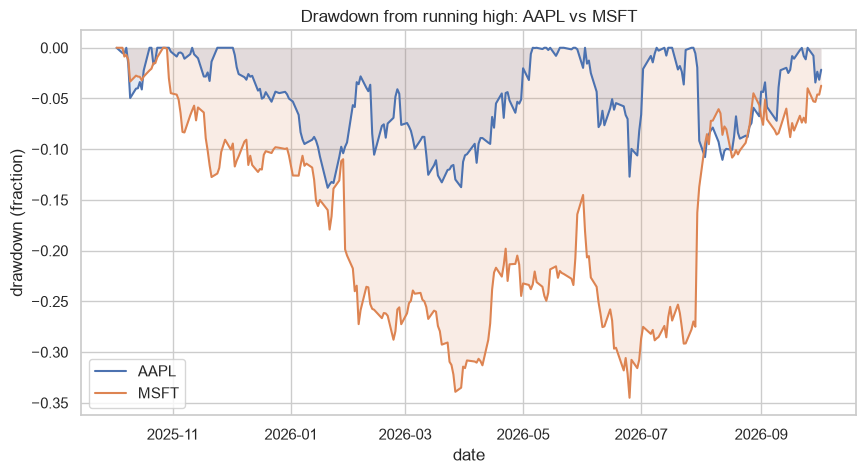

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
for col in prices.columns:
    dd = prices[col] / prices[col].cummax() - 1
    ax.plot(dd.index, dd, label=col, lw=1.5)
    ax.fill_between(dd.index, dd, 0, alpha=0.15)
ax.set_title(f"Drawdown from running high: {ticker} vs {other}")
ax.set_ylabel("drawdown (fraction)")
ax.set_xlabel("date")
ax.legend()
plt.show()

## Risk 2: Sharpe ratio (risk-adjusted return)

The Sharpe ratio divides the average return by the volatility of returns, then annualises
with `sqrt(252)`:

$$ \text{Sharpe} = \frac{\text{mean daily return}}{\text{std of daily returns}} \times \sqrt{252} $$

It answers: **how much return did I get for each unit of risk taken?** A high Sharpe means
smooth gains; a low or negative Sharpe means the ride was rough or the stock lost money.

**Simplification:** the textbook formula subtracts the *risk-free rate* (T-bills) from the
return before dividing. We take it as **zero** — fine for learning, but it slightly inflates
the ratio in a high-rate environment. Remember too that Sharpe treats up and down moves as
equally "risky", and it is only meaningful over comparable periods.

In [8]:
stats = pd.DataFrame({
    "sharpe_ratio": {c: sharpe_ratio(prices[c]) for c in prices.columns},
    "annualized_volatility": {c: annualized_volatility(prices[c]) for c in prices.columns},
    "max_drawdown": {c: max_drawdown(prices[c]) for c in prices.columns},
})
stats

,sharpe_ratio,annualized_volatility,max_drawdown
AAPL,1.187309,0.247364,-0.137985
MSFT,0.187201,0.328258,-0.344984


A quick visual capstone: the two risk measures side by side for both tickers.

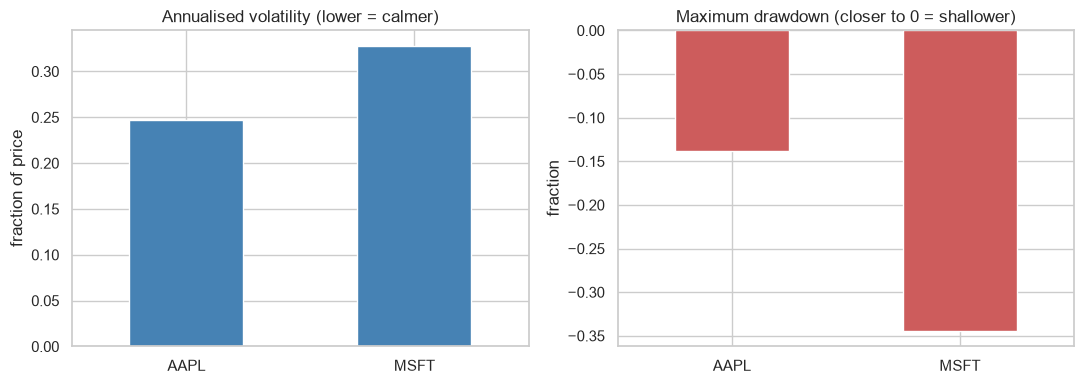

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
stats["annualized_volatility"].plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Annualised volatility (lower = calmer)")
axes[0].set_ylabel("fraction of price")
axes[0].tick_params(axis="x", rotation=0)

stats["max_drawdown"].plot.bar(ax=axes[1], color="indianred")
axes[1].set_title("Maximum drawdown (closer to 0 = shallower)")
axes[1].set_ylabel("fraction")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Recap / try this
- **Returns over levels:** simple returns measure wealth change; log returns add across time.
  The two converge for small moves and diverge for large ones.
- **Two stocks, one race:** inner-join prices first, then `cumprod(1 + returns)` to compare growth fairly.
- **Risk has a shape:** volatility is a single number, the drawdown curve shows the sequence of losses.
- **Sharpe = return per unit of risk**; here the risk-free rate is set to zero for simplicity.

Try:
1. Change `period` to `"5y"` and re-run — do the volatility rankings between AAPL and MSFT hold?
2. Add a third ticker (e.g. `"NVDA"`) to the watchlist and see which growth-of-\$1 curve wins.
3. Square the daily returns to plot **realised variance** over time, or compare a histogram with 20 vs 100 bins.
4. Compute the Sharpe ratio of the *difference* between the two stocks (a simple long-short) — what does it tell you?